In [1]:
!pip -q install dune-client

from google.colab import userdata
from dune_client.client import DuneClient

DUNE_API_KEY = userdata.get("DUNE_API_KEY")

dune = DuneClient(DUNE_API_KEY)
res = dune.get_latest_result(6697006)
res

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


ResultsResponse(execution_id='01KHEWKABMN6MT2NBSXWW8KYVK', query_id=6697006, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 2, 14, 20, 13, 43, 156131, tzinfo=tzlocal()), execution_started_at=datetime.datetime(2026, 2, 14, 20, 14, 4, 168450, tzinfo=tzlocal()), execution_ended_at=datetime.datetime(2026, 2, 14, 20, 15, 38, 595935, tzinfo=tzlocal()), expires_at=datetime.datetime(2026, 5, 15, 20, 15, 38, 595946, tzinfo=tzlocal()), cancelled_at=None), result=ExecutionResult(rows=[{'label': 'Burn', 'time': '2024-03-04 00:00:00.000 UTC', 'value': 125}, {'label': 'Mint', 'time': '2024-03-04 00:00:00.000 UTC', 'value': 200}, {'label': 'Burn', 'time': '2024-03-11 00:00:00.000 UTC', 'value': 75}, {'label': 'Mint', 'time': '2024-03-18 00:00:00.000 UTC', 'value': 100499706.87}, {'label': 'Mint', 'time': '2024-03-25 00:00:00.000 UTC', 'value': 174307546}, {'label': 'Burn', 'time': '2024-04-01 00:00:00.000 UTC', 'value': 250000}, {'label'

In [2]:
import pandas as pd

rows = res.result.rows
df = pd.DataFrame(rows)

df.head()

,label,time,value
0,Burn,2024-03-04 00:00:00.000 UTC,1.250000e+02
1,Mint,2024-03-04 00:00:00.000 UTC,2.000000e+02
2,Burn,2024-03-11 00:00:00.000 UTC,7.500000e+01
3,Mint,2024-03-18 00:00:00.000 UTC,1.004997e+08
4,Mint,2024-03-25 00:00:00.000 UTC,1.743075e+08


In [3]:
df.to_csv("buidl_eth_mint_burn_weekly.csv", index=False)
print("saved: buidl_eth_mint_burn_weekly.csv")

saved: buidl_eth_mint_burn_weekly.csv


In [16]:
df["time"] = pd.to_datetime(df["time"])

wide = (
    df.pivot_table(index="time", columns="label", values="value", aggfunc="sum")
      .fillna(0.0)
      .reset_index()
)

wide["net_flow"] = wide.get("Mint", 0.0) - wide.get("Burn", 0.0)  #net_flow = inflow - redemption outflow

wide.head()

label,time,Burn,Mint,net_flow
0,2024-03-04 00:00:00+00:00,125.0,2.000000e+02,7.500000e+01
1,2024-03-11 00:00:00+00:00,75.0,0.000000e+00,-7.500000e+01
2,2024-03-18 00:00:00+00:00,0.0,1.004997e+08,1.004997e+08
3,2024-03-25 00:00:00+00:00,0.0,1.743075e+08,1.743075e+08
4,2024-04-01 00:00:00+00:00,250000.0,6.098499e+06,5.848499e+06


## A)
 Describe on-chain issuance/redemption dynamics (weekly mint/burn and net flows), identify extreme redemption weeks for stress calibration.

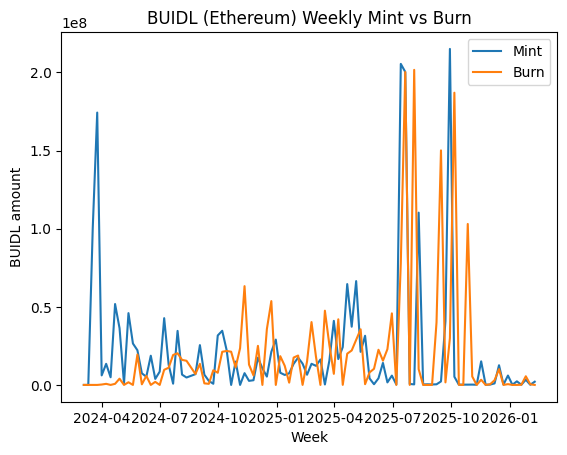

In [20]:
# A) On-chain Flow Monitoring
import matplotlib.pyplot as plt

# Rolling averages to reduce noise (4-week moving average)
wide["mint_4w_ma"] = wide["Mint"].rolling(4, min_periods=1).mean()
wide["burn_4w_ma"] = wide["Burn"].rolling(4, min_periods=1).mean()
wide["net_4w_ma"]  = wide["net_flow"].rolling(4, min_periods=1).mean()

# Plot 1: Mint vs Burn (weekly)
plt.figure()
plt.plot(wide["time"], wide["Mint"], label="Mint")
plt.plot(wide["time"], wide["Burn"], label="Burn")
plt.title("BUIDL (Ethereum) Weekly Mint vs Burn")
plt.xlabel("Week")
plt.ylabel("BUIDL amount")
plt.legend()
plt.show()


PLot 1: Weekly mint and burn flows are highly episodic, with rare but very large spikes. The largest activity clusters around 2025-07 to 2025-10, where extreme mints and burns co-occur, suggesting short windows of unusually high turnover

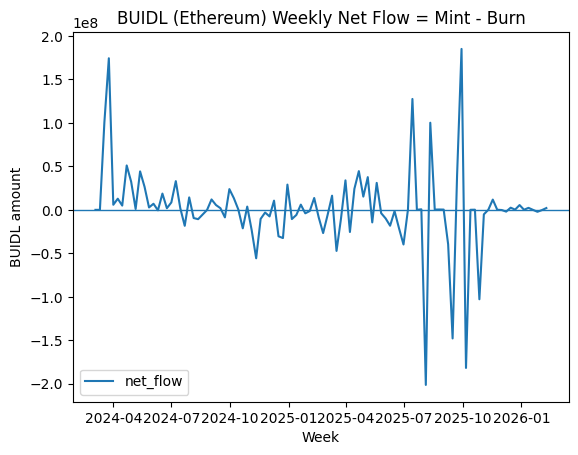

In [21]:
# Plot 2: Net flow (Mint - Burn)
plt.figure()
plt.plot(wide["time"], wide["net_flow"], label="net_flow")
plt.axhline(0, linewidth=1)
plt.title("BUIDL (Ethereum) Weekly Net Flow = Mint - Burn")
plt.xlabel("Week")
plt.ylabel("BUIDL amount")
plt.legend()
plt.show()


Plot 2:Net flow exhibits large sign flips in the same period, indicating that redemption pressure can materialize abruptly rather than gradually, motivating tail-based shock calibration (p95/p99/max) and an ALM-style liquidity gating simulation

In [22]:
# Top redemption weeks (largest burns)
top_burn = wide.sort_values("Burn", ascending=False).head(10)[["time", "Burn", "Mint", "net_flow"]]
print("Top 10 Burn weeks (largest redemption proxy):")
display(top_burn)

# how many weeks net outflow < 0?
net_outflow_weeks = (wide["net_flow"] < 0).sum()
print(f"Weeks with net outflow (net_flow < 0): {net_outflow_weeks} / {len(wide)}")

Top 10 Burn weeks (largest redemption proxy):


label,time,Burn,Mint,net_flow
73,2025-08-04 00:00:00+00:00,2.016505e+08,3.352896e+05,-2.013152e+08
71,2025-07-21 00:00:00+00:00,2.002703e+08,2.003423e+08,7.204420e+04
82,2025-10-06 00:00:00+00:00,1.870229e+08,5.239733e+06,-1.817832e+08
79,2025-09-15 00:00:00+00:00,1.501001e+08,2.222508e+06,-1.478776e+08
85,2025-10-27 00:00:00+00:00,1.030198e+08,1.828927e+05,-1.028369e+08
70,2025-07-14 00:00:00+00:00,7.796397e+07,2.054758e+08,1.275119e+08
35,2024-11-11 00:00:00+00:00,6.321892e+07,7.528891e+06,-5.569003e+07
41,2024-12-23 00:00:00+00:00,5.363906e+07,2.118982e+07,-3.244924e+07
53,2025-03-17 00:00:00+00:00,4.750048e+07,2.779294e+05,-4.722255e+07
68,2025-06-30 00:00:00+00:00,4.579638e+07,5.960283e+06,-3.983609e+07


Weeks with net outflow (net_flow < 0): 42 / 101


Net outflow weeks account for nearly 42% of the sample, which is not necessarily abnormal for a redeemable product, and flows are naturally two-sided. The key risk signal is the tail behavior: the largest burn weeks cluster in 2025-07 to 2025-10 and dominate redemption pressure, motivating percentile-based shock calibration and an issuer-side liquidity gating simulation

##B)
Shock Calibration from On-chain Burns identifies tail redemption weeks from on-chain burns, constructs a consistent burn-rate series (burn normalized by start-of-week outstanding supply proxy), and uses the empirical distribution to calibrate mild/stress/crisis redemption shocks (p95/p99/max) for the downstream ALM + gate/queue simulation.

In [23]:
# B1 — Top burn weeks (tail events)
top_burn = wide.sort_values("Burn", ascending=False).head(10)[
    ["time", "Burn", "Mint", "net_flow"]
]
top_burn

label,time,Burn,Mint,net_flow
73,2025-08-04 00:00:00+00:00,2.016505e+08,3.352896e+05,-2.013152e+08
71,2025-07-21 00:00:00+00:00,2.002703e+08,2.003423e+08,7.204420e+04
82,2025-10-06 00:00:00+00:00,1.870229e+08,5.239733e+06,-1.817832e+08
79,2025-09-15 00:00:00+00:00,1.501001e+08,2.222508e+06,-1.478776e+08
85,2025-10-27 00:00:00+00:00,1.030198e+08,1.828927e+05,-1.028369e+08
70,2025-07-14 00:00:00+00:00,7.796397e+07,2.054758e+08,1.275119e+08
35,2024-11-11 00:00:00+00:00,6.321892e+07,7.528891e+06,-5.569003e+07
41,2024-12-23 00:00:00+00:00,5.363906e+07,2.118982e+07,-3.244924e+07
53,2025-03-17 00:00:00+00:00,4.750048e+07,2.779294e+05,-4.722255e+07
68,2025-06-30 00:00:00+00:00,4.579638e+07,5.960283e+06,-3.983609e+07


In [25]:
# B2 — Build a consistent supply series (use burn_rate)
# Build an estimated circulating supply series from flows
wide["supply_end_est"] = wide["net_flow"].cumsum()

# Use start-of-week supply as denominator for burn rate
wide["supply_start_est"] = wide["supply_end_est"].shift(1)
wide.loc[wide["supply_start_est"] <= 0, "supply_start_est"] = pd.NA

wide["burn_rate"] = wide["Burn"] / wide["supply_start_est"]
wide[["time", "Burn", "supply_start_est", "burn_rate"]].dropna().head()

label,time,Burn,supply_start_est,burn_rate
1,2024-03-11 00:00:00+00:00,75.0,7.500000e+01,1.000000
3,2024-03-25 00:00:00+00:00,0.0,1.004997e+08,0.000000
4,2024-04-01 00:00:00+00:00,250000.0,2.748073e+08,0.000910
5,2024-04-08 00:00:00+00:00,691519.0,2.806558e+08,0.002464
6,2024-04-15 00:00:00+00:00,0.0,2.934644e+08,0.000000


In [12]:
# B3 — Calibrate shocks (p95/p99/max) + save to JSON
import json

x = wide["burn_rate"].dropna()
shocks = {
    "mild_p95": float(x.quantile(0.95)),
    "stress_p99": float(x.quantile(0.99)),
    "crisis_max": float(x.max()),
}

# Save for the ALM engine notebook/section
with open("shocks.json", "w") as f:
    json.dump(shocks, f, indent=2)

shocks

{'mild_p95': 0.3940418181517406,
 'stress_p99': 0.4336151692650026,
 'crisis_max': 1.0}

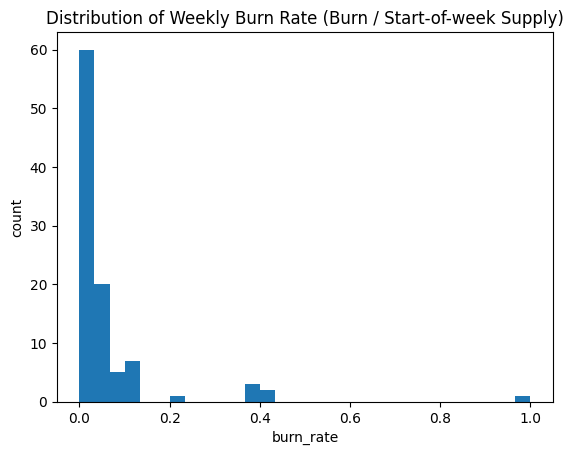

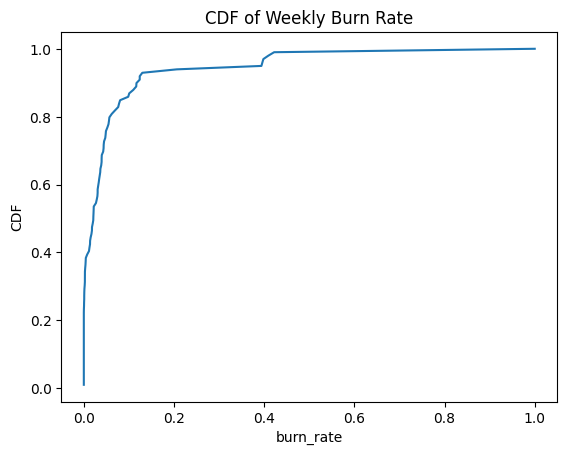

In [13]:
# B4 — Plot burn_rate distribution (hist + CDF)
# Histogram
plt.figure()
plt.hist(x, bins=30)
plt.title("Distribution of Weekly Burn Rate (Burn / Start-of-week Supply)")
plt.xlabel("burn_rate")
plt.ylabel("count")
plt.show()

# CDF
xs = x.sort_values().values
cdf = (pd.Series(range(1, len(xs)+1)) / len(xs)).values

plt.figure()
plt.plot(xs, cdf)
plt.title("CDF of Weekly Burn Rate")
plt.xlabel("burn_rate")
plt.ylabel("CDF")
plt.show()

The histogram is highly right-skewed:
most weeks exhibit very low burn rates (near zero), indicating that routine redemption pressure is typically modest. However, there is a sparse but meaningful right tail, with a few weeks showing materially higher burn rates (around ~0.4) and a rare extreme observation near 1.0. This pattern suggests that issuer liquidity risk is dominated by episodic tail events rather than day-to-day average flows.

The CDF rises quickly at low burn rates, confirming that the majority of weeks fall in the low-redemption regime. The curve then flattens and only approaches 1.0 at much higher burn rates, highlighting a small set of tail weeks that drive worst-case redemption pressure. This supports using percentile-based shocks: p95 and p99 capture “severe but plausible” outflow scenarios, while the max represents a crisis-level historical stress for conservative gating/queue simulations.


##C)
Runs a simplified issuer-side liquidity stress test: given an AUM proxy and a calibrated redemption shock, simulate weekly cash flows under constraints (cash buffer, asset sale limits, settlement lag, haircut) and a gating rule (threshold + max weekly payout); then plot the queued redemption share over time and summarize key KPIs (peak queue %, weeks gated, end-of-horizon queue) across mild/stress/crisis scenarios.

The following cell defines a weekly issuer-side liquidity simulation under a redemption shock: redemption requests accumulate into a queue, the issuer pays from an initial cash buffer (subject to a gate/max weekly payout rule), and can liquidate assets up to a weekly sell limit with haircut and settlement lag (proceeds arrive later via a cash pipeline). The function returns the full weekly time series and summary KPIs (peak queue %, weeks gated, ending queue).

In [26]:
import numpy as np
import pandas as pd

def run_alm_one_shock(
    aum: float,
    shock_rate: float,
    shock_weeks: int = 1,
    baseline_rate: float = 0.0,

    cash_buffer_pct: float = 0.03,  # initial liquid cash as % of AUM
    sell_limit_pct_per_week: float = 0.05,  # max asset liquidation per week (% of AUM)
    settlement_lag_weeks: int = 1,  # sale proceeds arrive after this many weeks
    haircut: float = 0.002,   # liquidation friction / slippage

    gate_threshold_pct: float = 0.02, # gate triggers if queue/AUM exceeds this
    max_pay_pct_per_week: float = 0.01, # when gated, max payout per week (% of AUM)

    horizon_weeks: int = 30
):
    # --- state ---
    cash = cash_buffer_pct * aum  # available cash today (can pay immediately)
    queue = 0.0 # unpaid redemption requests (dollar amount)

    # pipeline[k] = cash arriving in k weeks (k=0 means available now)
    settlement_lag_weeks = max(int(settlement_lag_weeks), 0)
    pipeline = [0.0] * (settlement_lag_weeks + 1)

    history = []
    for t in range(horizon_weeks):

        # 1) Receive any matured sale proceeds (settled cash)
        cash += pipeline.pop(0)
        if len(pipeline) == 0:
            pipeline = [0.0]  # safety for lag=0 edge case

        # 2) Add new redemption demand to the queue
        #    Shock applies for the first shock_weeks, then reverts to baseline
        demand_rate = shock_rate if t < shock_weeks else baseline_rate
        weekly_demand = demand_rate * aum
        queue += weekly_demand

        # 3) gate rule (based on current queue)
        queue_pct = queue / aum
        is_gated = queue_pct > gate_threshold_pct

        # If gated, issuer can only pay up to max_pay% of AUM this week
        payout_cap = (max_pay_pct_per_week * aum) if is_gated else np.inf

        # 4) Pay redemptions from cash (ONLY cash payments reduce the queue)
        pay = min(cash, queue, payout_cap)
        cash -= pay
        queue -= pay
        payout_cap = payout_cap - pay  # remaining cap (inf stays inf)

        # 5) sell assets to raise future cash (does NOT reduce queue today)
        max_sale = sell_limit_pct_per_week * aum
        sale_commit = min(queue, payout_cap, max_sale) if np.isfinite(payout_cap) else min(queue, max_sale)

        # Sale proceeds arrive after settlement lag and incur a haircut
        proceeds = sale_commit * (1 - haircut)
        pipeline[-1] += proceeds

        history.append({
            "week": t,
            "weekly_demand": weekly_demand,
            "cash": cash,
            "queue": queue,
            "queue_pct": queue / aum,
            "is_gated": is_gated,
            "sale_commit": sale_commit,
            "pay": pay
        })

    hist = pd.DataFrame(history)
    kpis = {
        "shock_rate": float(shock_rate),
        "shock_weeks": int(shock_weeks),
        "max_queue_pct": float(hist["queue_pct"].max()),
        "weeks_gated": int(hist["is_gated"].sum()),
        "queue_end_pct": float(hist["queue_pct"].iloc[-1]),
    }
    return hist, kpis

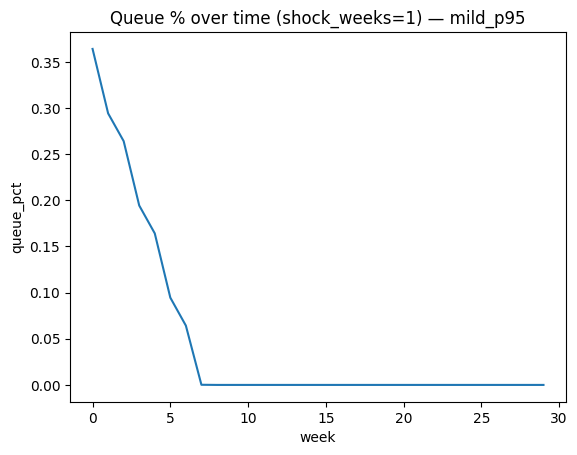

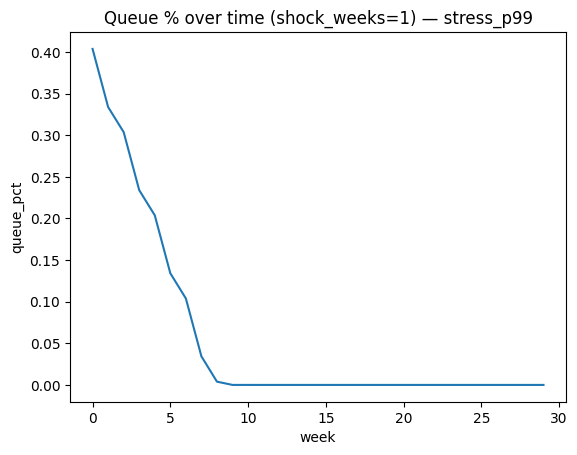

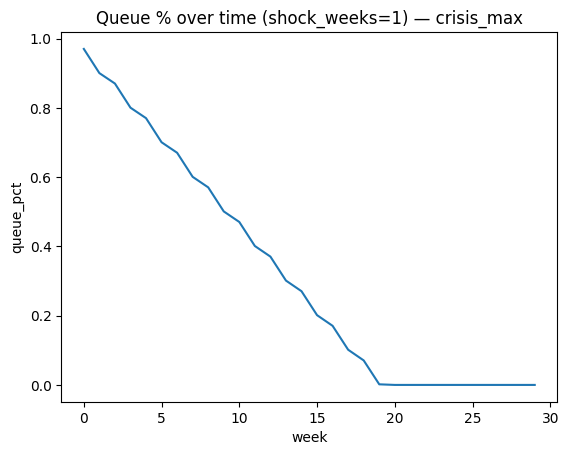

In [30]:
# Run scenarios from shocks.json + plot queue%
import json

with open("shocks.json", "r") as f:
    shocks = json.load(f)

AUM = float(wide["supply_end_est"].iloc[-1])  # rough proxy; or set AUM = latest supply from Etherscan

scenarios = {
    "mild_p95": shocks["mild_p95"],
    "stress_p99": shocks["stress_p99"],
    "crisis_max": shocks["crisis_max"],
}

all_kpis = []
for name, sr in scenarios.items():
  # Run one shock scenario through the issuer ALM + gate/queue simulator
  # shock_rate = weekly redemption demand as % of AUM (calibrated from on-chain burns)
  hist, kpi = run_alm_one_shock(
      aum=AUM,                    # scale for cash/queue in dollars; KPIs reported as %AUM
      shock_rate=sr,              # scenario shock intensity (p95/p99/max)
      shock_weeks=1,              # assume a 1-week spike then revert (tail-event style stress)

      cash_buffer_pct=0.03,       # starting liquid cash (immediate pay capacity)
      sell_limit_pct_per_week=0.10, # weekly liquidation capacity limit (%AUM)
      settlement_lag_weeks=1,     # proceeds settle with a 1-week delay
      haircut=0.0025,             # liquidation friction / slippage

      max_pay_pct_per_week=0.10,    # when gated, max payout per week (%AUM)
      gate_threshold_pct=0.05,      # gate triggers when queue exceeds 5% of AUM
      horizon_weeks=30,
  )
  kpi["scenario"] = name
  all_kpis.append(kpi)

  plt.figure()
  plt.plot(hist["week"], hist["queue_pct"])
  plt.title(f"Queue % over time (shock_weeks=1) — {name}")
  plt.xlabel("week")
  plt.ylabel("queue_pct")
  plt.show()


The mild (p95) scenario produces an initial queue of roughly ~36% of AUM, reflecting delayed redemptions after a one-week shock. The backlog is paid down quickly and clears by ~week 7–8, suggesting manageable short-term liquidity stress under the assumed policy constraints.

Under the stress (p99) shock, the queue peaks around ~40% of AUM and then declines steadily. The queue clears by ~week 8–9, indicating a slightly longer but still finite delay window compared with the mild case.

The crisis (max) scenario generates a near-total backlog (~97% of AUM queued initially), implying severe redemption pressure. The queue is reduced gradually and takes ~19–20 weeks to fully clear, consistent with binding liquidation/settlement constraints and prolonged gating under extreme conditions.


In [31]:
kpi_df = pd.DataFrame(all_kpis).sort_values("max_queue_pct", ascending=False)
kpi_df

,shock_rate,shock_weeks,max_queue_pct,weeks_gated,queue_end_pct,scenario
2,1.000000,1,0.970000,20,1.658389e-29,crisis_max
1,0.433615,1,0.403615,8,8.909419e-58,stress_p99
0,0.394042,1,0.364042,8,9.133156e-62,mild_p95


The KPI table shows a monotonic relationship between shock severity and liquidity outcomes. Peak queued redemptions (max_queue_pct) rise from ~36% (mild p95) to ~40% (stress p99) and to ~97% under the crisis max shock, with gating duration (weeks_gated) extending from ~8 weeks to ~20 weeks in the crisis case. queue_end_pct ≈ 0 across all scenarios by week 30, indicating that backlogs are eventually cleared under the assumed liquidation capacity and settlement lag.